# **Tugas Besar Data Mining - Part 1**

---

Anggota Kelompok:

-102022400067    Paris

-102022400137    I Putu Gede Aris Pramana

-102022400303    Bravislampa

-102022430039    Muhammad Nur Rizqi

Kelas: SI-48-03

Nama Dosen: Dita Pramesti

---

## Studi Kasus

Dalam studi kasus ini, kita akan melakukan berbagai proses Data Cleansing, Data Reduction, Missing Value Handling, dan Data Transformation pada dataset yang berkaitan dengan kendaraan BMW. Dataset ini terdiri dari informasi mengenai berbagai model BMW dengan detail spesifikasi, harga, performa, dan kondisi kendaraan dari berbagai tahun. Data ini mengumpulkan informasi tentang karakteristik teknis dan ekonomis dari kendaraan BMW yang tersedia di pasaran.

### 📄 Informasi Dataset

Dataset ini terdiri dari data kendaraan BMW dengan fitur-fitur yang menjelaskan karakteristik setiap unit kendaraan. Dataset mencakup informasi berikut:

1. **model**: Model kendaraan BMW (contoh: 5 Series, 6 Series, 1 Series, 2 Series, 3 Series, 4 Series, 7 Series, X3, dll).
2. **year**: Tahun pembuatan kendaraan (berkisar dari berbagai tahun).
3. **price**: Harga kendaraan dalam mata uang tertentu.
4. **transmission**: Jenis transmisi kendaraan (Automatic atau Manual).
5. **mileage**: Jarak tempuh kendaraan dalam mil atau kilometer.
6. **fuelType**: Jenis bahan bakar yang digunakan (Diesel, Petrol, atau Other).
7. **tax**: Jumlah pajak kendaraan tahunan.
8. **mpg**: Efisiensi bahan bakar dalam miles per gallon (MPG) - seberapa jauh kendaraan dapat menempuh perjalanan dengan satu satuan bahan bakar.
9. **engineSize**: Ukuran mesin kendaraan dalam liter - mengindikasikan kapasitas dan daya mesin.

---

### Library

Harap untuk diperhatikan, jika library terjadi error ataupun sejenisnya. Silahkan jalankan kode dibawah ini dengan menghapus tanda '#'.

In [3]:
# Jika belum punya library python dibawah ini, silahkan jalankan code dibawah ini
%pip install "pandas>=2.0.0" "numpy>=1.24.0" "scikit-learn>=1.2.2" "matplotlib>=3.7.1" "seaborn>=0.12.2"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## **Read Data**

Pertama, kita akan membaca dataset menggunakan library pandas dan menampilkan beberapa baris awal untuk memahami struktur data.

In [5]:
import pandas as pd
df = pd.read_csv('bmw.csv')

## **Data Cleansing**

### Duplikasi data

Selanjutnya, kita akan melakukan pengecekan apakah ada data yang duplikat dalam dataset. 

Jika ada data yang duplikat, kita menghapusnya karena data duplikat dapat mempengaruhi hasil analisis.

Cek data duplikasi

In [23]:
df.info()
duplicated =df.duplicated().sum()
print("Jumlah duplikat yang ditemukan:\n", duplicated)

<class 'pandas.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  str    
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  str    
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  str    
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 758.2 KB
Jumlah duplikat yang ditemukan:
 117


Drop duplikasi data

In [17]:
df_cleaned = df.drop_duplicates()


Tampilkan Keseluruhan data untuk dicek

In [19]:
print(f"Jumlah baris sebelum drop duplikat: {len(df)}")
print(f"Jumlah baris setelah drop duplikat: {len(df_cleaned)}")
print(f"Jumlah baris yang dihapus: {len(df) - len(df_cleaned)}")
info = df_cleaned.info()

Jumlah baris sebelum drop duplikat: 10781
Jumlah baris setelah drop duplikat: 10664
Jumlah baris yang dihapus: 117
<class 'pandas.DataFrame'>
Index: 10664 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10664 non-null  str    
 1   year          10664 non-null  int64  
 2   price         10664 non-null  int64  
 3   transmission  10664 non-null  str    
 4   mileage       10664 non-null  int64  
 5   fuelType      10664 non-null  str    
 6   tax           10664 non-null  int64  
 7   mpg           10664 non-null  float64
 8   engineSize    10664 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 833.1 KB


### Data Null

gy87444444444444444444444444444444444444444444444444444444*Pada dataset BMW ini, kita akan memeriksa apakah terdapat nilai yang hilang (missing /values) di setiap kolom. Jika ada, kita akan menghapus baris-baris yang mengandung nilai kosong untuk memastikan kualitas data.

Melihat info dari data

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3472 entries, 0 to 3471
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country_name                     3472 non-null   str    
 1   country_id                       3472 non-null   str    
 2   year                             3472 non-null   int64  
 3   Inflation (CPI %)                2694 non-null   float64
 4   GDP (Current USD)                2933 non-null   float64
 5   GDP per Capita (Current USD)     2938 non-null   float64
 6   Unemployment Rate (%)            2795 non-null   float64
 7   Interest Rate (Real, %)          1735 non-null   float64
 8   Inflation (GDP Deflator, %)      2904 non-null   float64
 9   GDP Growth (% Annual)            2912 non-null   float64
 10  Current Account Balance (% GDP)  2563 non-null   float64
 11  Government Expense (% of GDP)    1820 non-null   float64
 12  Government Revenue (% of GDP)  

Cek total nilai null didalam tiap kolom

In [ ]:
print('Total nilai null di setiap kolom:')
print(df.isnull().sum())

      country_name  country_id   year  Inflation (CPI %)  GDP (Current USD)  \
0            False       False  False              False              False   
1            False       False  False              False              False   
2            False       False  False              False              False   
3            False       False  False              False              False   
4            False       False  False              False              False   
...            ...         ...    ...                ...                ...   
3465         False       False  False              False              False   
3466         False       False  False              False              False   
3467         False       False  False              False              False   
3468         False       False  False              False              False   
3469         False       False  False               True              False   

      GDP per Capita (Current USD)  Unemployment Ra

Drop baris yang memiliki nilai null

In [ ]:
df = df.dropna()

Cek hasil drop nilai null

In [ ]:
print(df.isnull().sum())
print(f"\nTotal baris setelah drop nilai null: {len(df)}")

country_name                          0
country_id                            0
year                                  0
Inflation (CPI %)                   378
GDP (Current USD)                     0
GDP per Capita (Current USD)          0
Unemployment Rate (%)               379
Interest Rate (Real, %)            1208
Inflation (GDP Deflator, %)          31
GDP Growth (% Annual)                29
Current Account Balance (% GDP)     381
Government Expense (% of GDP)      1114
Government Revenue (% of GDP)      1105
Tax Revenue (% of GDP)             1101
Gross National Income (USD)         137
Public Debt (% of GDP)             2081
dtype: int64

Total baris setelah drop nilai null: 2933


### Drop kolom yang tidak di butuhkan

Semua kolom dalam dataset BMW sudah relevan untuk analisis, sehingga tidak ada kolom yang perlu dihapus.

In [ ]:
print('Kolom yang tersedia dalam dataset:')
print(df.columns.tolist())

country_name                          0
country_id                            0
year                                  0
Inflation (CPI %)                   378
GDP (Current USD)                     0
GDP per Capita (Current USD)          0
Unemployment Rate (%)               379
Interest Rate (Real, %)            1208
Inflation (GDP Deflator, %)          31
GDP Growth (% Annual)                29
Current Account Balance (% GDP)     381
Government Expense (% of GDP)      1114
Government Revenue (% of GDP)      1105
Tax Revenue (% of GDP)             1101
Gross National Income (USD)         137
Public Debt (% of GDP)             2081
dtype: int64


Cek Info data

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 2933 entries, 0 to 3469
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country_name                     2933 non-null   str    
 1   country_id                       2933 non-null   str    
 2   year                             2933 non-null   int64  
 3   Inflation (CPI %)                2555 non-null   float64
 4   GDP (Current USD)                2933 non-null   float64
 5   GDP per Capita (Current USD)     2933 non-null   float64
 6   Unemployment Rate (%)            2554 non-null   float64
 7   Interest Rate (Real, %)          1725 non-null   float64
 8   Inflation (GDP Deflator, %)      2902 non-null   float64
 9   GDP Growth (% Annual)            2904 non-null   float64
 10  Current Account Balance (% GDP)  2552 non-null   float64
 11  Government Expense (% of GDP)    1819 non-null   float64
 12  Government Revenue (% of GDP)    182

Tampilkan ringkasan dataset

In [ ]:
print('Ringkasan dataset BMW:')
print(f"Jumlah baris: {len(df)}")
print(f"Jumlah kolom: {len(df.columns)}")

Cek Info data

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 2933 entries, 0 to 3469
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country_name                     2933 non-null   str    
 1   year                             2933 non-null   int64  
 2   Inflation (CPI %)                2555 non-null   float64
 3   GDP (Current USD)                2933 non-null   float64
 4   GDP per Capita (Current USD)     2933 non-null   float64
 5   Unemployment Rate (%)            2554 non-null   float64
 6   Interest Rate (Real, %)          1725 non-null   float64
 7   Inflation (GDP Deflator, %)      2902 non-null   float64
 8   GDP Growth (% Annual)            2904 non-null   float64
 9   Current Account Balance (% GDP)  2552 non-null   float64
 10  Government Expense (% of GDP)    1819 non-null   float64
 11  Government Revenue (% of GDP)    1828 non-null   float64
 12  Tax Revenue (% of GDP)           183

## **Missing Value Handling**

### Analisis Kolom Numerik

Kami akan menganalisis kolom-kolom numerik pada dataset BMW untuk memahami distribusi data, khususnya pada kolom **price, mileage, tax, mpg, dan engineSize**. Ini penting untuk menentukan strategi transformasi data yang tepat.

Tampilkan ringkasan statistik

In [ ]:
print('Ringkasan statistik dataset BMW:')
print(df.describe())

      country_name   year  Inflation (CPI %)  GDP (Current USD)  \
0            False  False              False              False   
1            False  False              False              False   
2            False  False              False              False   
3            False  False              False              False   
4            False  False              False              False   
...            ...    ...                ...                ...   
3465         False  False              False              False   
3466         False  False              False              False   
3467         False  False              False              False   
3468         False  False              False              False   
3469         False  False               True              False   

      GDP per Capita (Current USD)  Unemployment Rate (%)  \
0                            False                   True   
1                            False                   True   
2           

Buatlah grafik histogram pada semua kolom menggunakan matplotlib

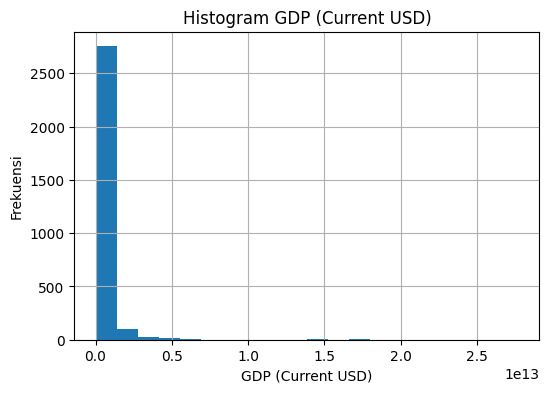

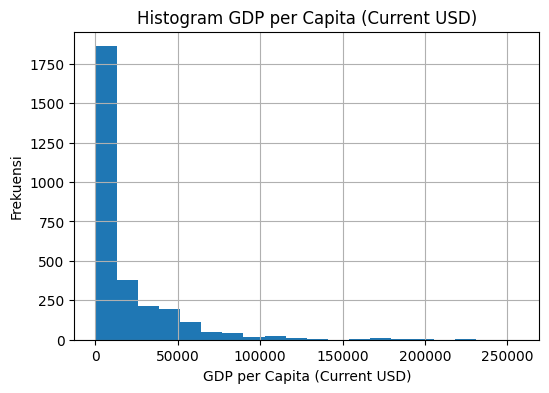

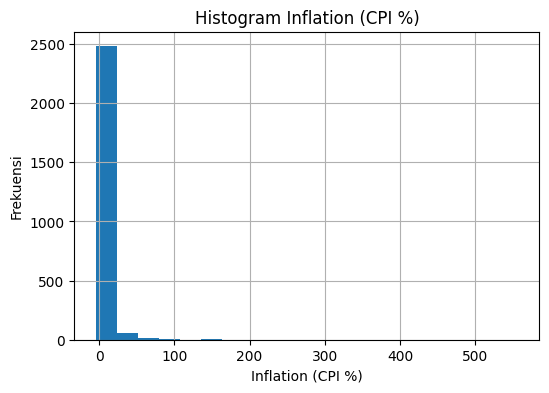

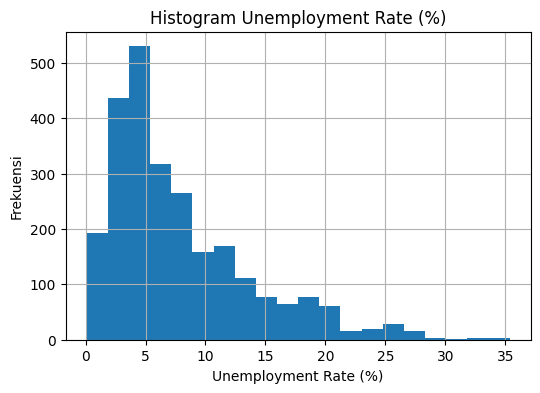

In [ ]:
import matplotlib.pyplot as plt

numeric_columns = ['price', 'mileage', 'tax', 'mpg', 'engineSize']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for idx, col in enumerate(numeric_columns):
    axes[idx].hist(df[col], bins=20, edgecolor='black')
    axes[idx].set_title(f'Histogram {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frekuensi')
plt.tight_layout()
plt.show()

Analisis distribusi kategori dalam dataset

In [ ]:
print('Distribusi model BMW:')
print(df['model'].value_counts())
print('\nDistribusi transmisi:')
print(df['transmission'].value_counts())
print('\nDistribusi jenis bahan bakar:')
print(df['fuelType'].value_counts())

Tampilkan statistik deskriptif per kategori

In [ ]:
print('Rata-rata harga per model BMW:')
print(df.groupby('model')['price'].mean().sort_values(ascending=False))
print('\nRata-rata efisiensi bahan bakar (MPG) per jenis bahan bakar:')
print(df.groupby('fuelType')['mpg'].mean().sort_values(ascending=False))

Total nilai null pada kolom mean setelah imputasi:
Interest Rate (Real, %)            0
GDP Growth (% Annual)              0
Current Account Balance (% GDP)    0
Government Expense (% of GDP)      0
Government Revenue (% of GDP)      0
Tax Revenue (% of GDP)             0
dtype: int64


Cek 10 data teratas

In [ ]:
df.head(10)

,country_name,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD)
0,Aruba,2010,2.078141,2.453597e+09,24093.140151,NaN,11.666131,-1.223407,-2.733457,-18.752537,27.318244,26.677669,16.966214,2.313385e+09
1,Aruba,2011,4.316297,2.637859e+09,25712.384302,NaN,4.801974,4.005674,3.369237,-9.877656,27.318244,26.677669,16.966214,2.391841e+09
2,Aruba,2012,0.627472,2.615208e+09,25119.665545,NaN,8.200875,0.184033,-1.040800,3.473451,27.318244,26.677669,16.966214,2.499118e+09
3,Aruba,2013,-2.372065,2.727850e+09,25813.576727,NaN,10.709709,-1.995948,6.431483,-11.813206,27.318244,26.677669,16.966214,2.563517e+09
4,Aruba,2014,0.421441,2.790850e+09,26129.839062,NaN,3.213869,3.958897,-1.586575,-4.658577,27.318244,26.677669,16.966214,2.688102e+09
5,Aruba,2015,0.474764,2.962907e+09,27458.225331,NaN,0.157925,6.831287,-0.623626,3.994142,27.318244,26.677669,16.966214,2.838144e+09
6,Aruba,2016,-0.931196,2.983635e+09,27441.529662,NaN,7.982852,-1.002800,1.719625,4.731778,27.318244,26.677669,16.966214,2.848406e+09
7,Aruba,2017,-1.028282,3.092429e+09,28440.051964,NaN,9.789287,-3.178167,7.048533,1.119795,27.318244,26.677669,16.966214,2.921801e+09
8,Aruba,2018,3.626041,3.276184e+09,30082.127645,NaN,2.453045,3.462030,2.397085,-0.591367,27.318244,26.677669,16.966214,3.061557e+09
9,Aruba,2019,4.257462,3.395799e+09,31096.205074,NaN,-0.299776,6.017816,-2.232440,2.497110,27.318244,26.677669,16.966214,3.242394e+09


### Korelasi antar variabel numerik

Kita akan melihat korelasi antara kolom-kolom numerik untuk memahami hubungan antar variabel. Korelasi positif berarti ketika satu variabel meningkat, variabel lain juga cenderung meningkat. Sebaliknya untuk korelasi negatif.

Hitung matriks korelasi

In [ ]:
import seaborn as sns

correlation_matrix = df[['price', 'mileage', 'tax', 'mpg', 'engineSize', 'year']].corr()
print('Matriks Korelasi:')
print(correlation_matrix)

Total nilai null di setiap kolom untuk median:
country_name                         0
year                                 0
Inflation (CPI %)                  378
GDP (Current USD)                    0
GDP per Capita (Current USD)         0
Unemployment Rate (%)              379
Interest Rate (Real, %)              0
Inflation (GDP Deflator, %)         31
GDP Growth (% Annual)                0
Current Account Balance (% GDP)      0
Government Expense (% of GDP)        0
Government Revenue (% of GDP)        0
Tax Revenue (% of GDP)               0
Gross National Income (USD)        137
dtype: int64


Visualisasikan matriks korelasi dengan heatmap

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriks Korelasi Dataset BMW')
plt.tight_layout()
plt.show()

Tampilkan data teratas

In [ ]:
print(df.head())

Total nilai null pada kolom median setelah imputasi:
Inflation (CPI %)              0
Unemployment Rate (%)          0
Inflation (GDP Deflator, %)    0
Gross National Income (USD)    0
dtype: int64

Total nilai null di seluruh dataframe:
country_name                       0
year                               0
Inflation (CPI %)                  0
GDP (Current USD)                  0
GDP per Capita (Current USD)       0
Unemployment Rate (%)              0
Interest Rate (Real, %)            0
Inflation (GDP Deflator, %)        0
GDP Growth (% Annual)              0
Current Account Balance (% GDP)    0
Government Expense (% of GDP)      0
Government Revenue (% of GDP)      0
Tax Revenue (% of GDP)             0
Gross National Income (USD)        0
dtype: int64


Keseluruhan data

In [ ]:
df.head(10)

,country_name,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD)
0,Aruba,2010,2.078141,2.453597e+09,24093.140151,5.8965,11.666131,-1.223407,-2.733457,-18.752537,27.318244,26.677669,16.966214,2.313385e+09
1,Aruba,2011,4.316297,2.637859e+09,25712.384302,5.8965,4.801974,4.005674,3.369237,-9.877656,27.318244,26.677669,16.966214,2.391841e+09
2,Aruba,2012,0.627472,2.615208e+09,25119.665545,5.8965,8.200875,0.184033,-1.040800,3.473451,27.318244,26.677669,16.966214,2.499118e+09
3,Aruba,2013,-2.372065,2.727850e+09,25813.576727,5.8965,10.709709,-1.995948,6.431483,-11.813206,27.318244,26.677669,16.966214,2.563517e+09
4,Aruba,2014,0.421441,2.790850e+09,26129.839062,5.8965,3.213869,3.958897,-1.586575,-4.658577,27.318244,26.677669,16.966214,2.688102e+09
5,Aruba,2015,0.474764,2.962907e+09,27458.225331,5.8965,0.157925,6.831287,-0.623626,3.994142,27.318244,26.677669,16.966214,2.838144e+09
6,Aruba,2016,-0.931196,2.983635e+09,27441.529662,5.8965,7.982852,-1.002800,1.719625,4.731778,27.318244,26.677669,16.966214,2.848406e+09
7,Aruba,2017,-1.028282,3.092429e+09,28440.051964,5.8965,9.789287,-3.178167,7.048533,1.119795,27.318244,26.677669,16.966214,2.921801e+09
8,Aruba,2018,3.626041,3.276184e+09,30082.127645,5.8965,2.453045,3.462030,2.397085,-0.591367,27.318244,26.677669,16.966214,3.061557e+09
9,Aruba,2019,4.257462,3.395799e+09,31096.205074,5.8965,-0.299776,6.017816,-2.232440,2.497110,27.318244,26.677669,16.966214,3.242394e+09


## Outliers Handling

Outlier adalah data yang tidak lazim atau sangat berbeda dari data lainnya. Pada kasus ini, kita akan mendeteksi outlier pada semua kolom menggunakan metode Interquartile Range (IQR), dan menghapus data yang berada di luar batas.

Tampilkan ringkasan statistik dari data

In [ ]:
df.describe()

,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD)
count,2933.000000,2933.000000,2.933000e+03,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2.933000e+03
mean,2016.431640,5.466528,3.964323e+11,18514.051102,7.665788,5.559083,6.461556,2.868774,-2.330373,27.318244,26.677669,16.966214,3.962704e+11
std,4.015044,15.833903,1.749315e+12,27315.039416,5.649217,7.155472,24.636550,6.017727,12.802991,9.954991,14.304558,6.495226,1.759103e+12
min,2010.000000,-4.644709,3.210541e+07,193.007146,0.100000,-81.132121,-28.760135,-54.336155,-60.877754,0.000136,0.000081,0.000063,5.107533e+07
25%,2013.000000,1.605812,6.264757e+09,2307.344684,4.000000,4.145068,1.226998,1.038551,-6.541608,23.008821,21.747880,14.522319,8.456916e+09
50%,2016.000000,3.219887,2.587360e+10,6839.725039,5.896500,5.559083,3.220793,3.073045,-2.330373,27.318244,26.677669,16.966214,2.986520e+10
75%,2020.000000,5.686320,1.874939e+11,23785.754590,9.713000,6.151412,6.843980,5.336973,1.119795,29.270389,28.165934,17.998857,1.831965e+11
max,2023.000000,557.201817,2.772071e+13,256580.515123,35.359000,61.882604,921.535652,86.826748,235.750605,103.725787,344.999451,147.640196,2.757614e+13


Buat grafik Boxplot semua colums Outlier menggunakan library matplotlib dan pandas

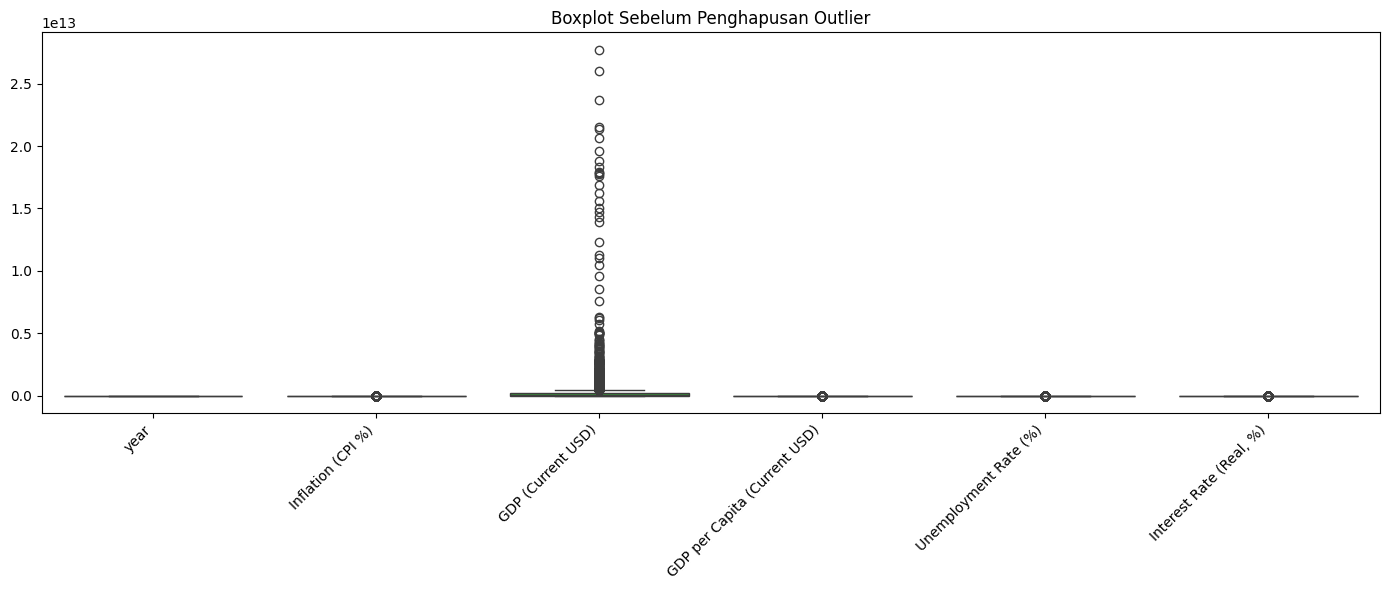

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns[:6]
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45, ha='right')
plt.title('Boxplot Sebelum Penghapusan Outlier')
plt.tight_layout()
plt.show()

Drop Data yang outlier

In [ ]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df_cleaned_outliers = df.copy()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned_outliers = df_cleaned_outliers[(df_cleaned_outliers[col] >= lower_bound) & (df_cleaned_outliers[col] <= upper_bound)]

Print total baris sebelum outlier dihapus dan sesudah dihapus. Serta inisiasikan variabel data yang telah bersih ke dalam df kembali (df = variabel data yang telah bersih)

In [ ]:
print(f"Total baris sebelum drop outlier: {len(df)}")
print(f"Total baris setelah drop outlier: {len(df_cleaned_outliers)}")
print(f"Jumlah baris yang dihapus: {len(df) - len(df_cleaned_outliers)}")

# Update df dengan data yang sudah bersih
df = df_cleaned_outliers

Total baris sebelum drop outlier: 2933
Total baris setelah drop outlier: 852
Jumlah baris yang dihapus: 2081


Buat grafik Boxplot semua colums setelah pembersihan Outlier

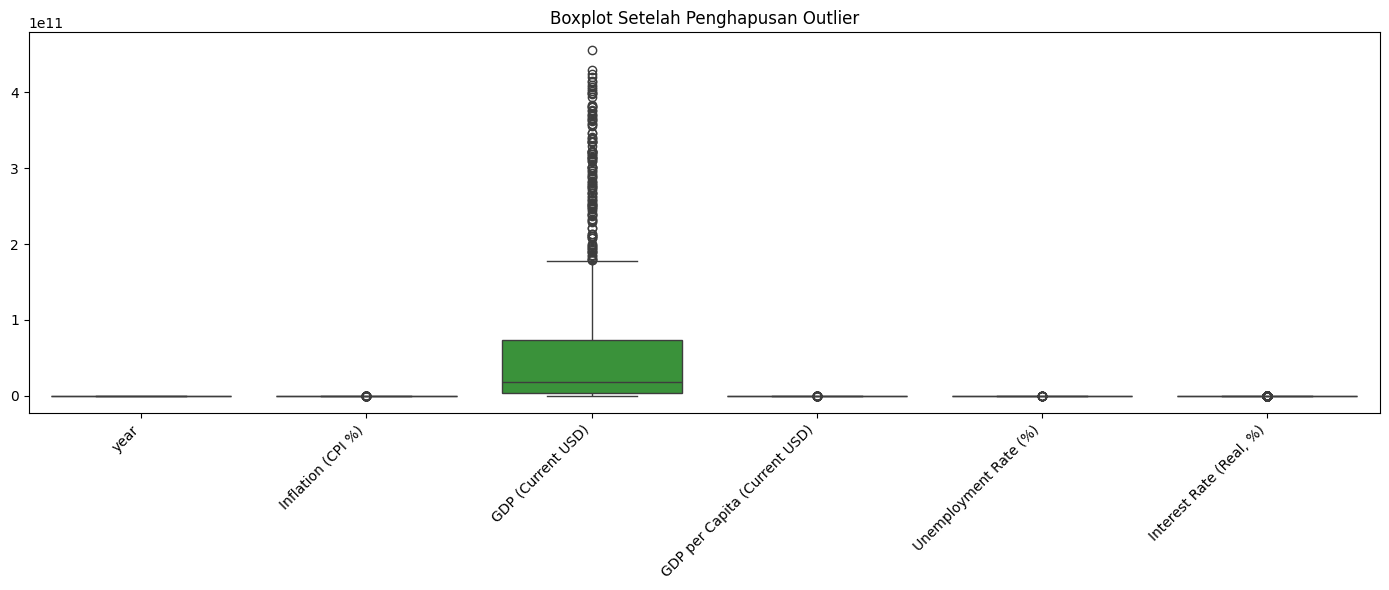

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns[:6]  # First 6 numeric columns
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45, ha='right')
plt.title('Boxplot Setelah Penghapusan Outlier')
plt.tight_layout()
plt.show()

Cek info data

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 852 entries, 1 to 3462
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country_name                     852 non-null    str    
 1   year                             852 non-null    int64  
 2   Inflation (CPI %)                852 non-null    float64
 3   GDP (Current USD)                852 non-null    float64
 4   GDP per Capita (Current USD)     852 non-null    float64
 5   Unemployment Rate (%)            852 non-null    float64
 6   Interest Rate (Real, %)          852 non-null    float64
 7   Inflation (GDP Deflator, %)      852 non-null    float64
 8   GDP Growth (% Annual)            852 non-null    float64
 9   Current Account Balance (% GDP)  852 non-null    float64
 10  Government Expense (% of GDP)    852 non-null    float64
 11  Government Revenue (% of GDP)    852 non-null    float64
 12  Tax Revenue (% of GDP)           852 

## **Data Reduction**

### PCA

PCA digunakan untuk mengurangi dimensi data tanpa kehilangan terlalu banyak informasi. Dalam kasus ini, kita menggunakan PCA untuk mengekstrak dua komponen utama dari data yang telah dinormalisasi.

**note: Hasil PCA tidak digunakan pada tahap selanjutnya, untuk proses data reduction gunakan: df_4NIM TERAKHIR = df_PCA**

Library yang digunakan: **sklearn.decomposition (PCA), numpy, sklearn.preprocessing (StandardScaler)**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Pilih kolom numerik yang ingin digunakan

Menggunakan kolom **price, mileage, tax, mpg, engineSize, dan year** sebagai fitur utama untuk PCA.

In [ ]:
pca_columns = ['price', 'mileage', 'tax', 'mpg', 'engineSize', 'year']

X = df[pca_columns]
print(f"Data sebelum PCA shape: {X.shape}")
print(f"\nKolom yang digunakan: {pca_columns}")
print(f"\n5 data teratas:")
print(X.head())

Data sebelum PCA shape: (852, 12)
   Inflation (CPI %)  GDP (Current USD)  GDP per Capita (Current USD)  \
1           4.316297       2.637859e+09                  25712.384302   
2           0.627472       2.615208e+09                  25119.665545   
4           0.421441       2.790850e+09                  26129.839062   
6          -0.931196       2.983635e+09                  27441.529662   
8           3.626041       3.276184e+09                  30082.127645   

   Unemployment Rate (%)  Interest Rate (Real, %)  \
1                 5.8965                 4.801974   
2                 5.8965                 8.200875   
4                 5.8965                 3.213869   
6                 5.8965                 7.982852   
8                 5.8965                 2.453045   

   Inflation (GDP Deflator, %)  GDP Growth (% Annual)  \
1                     4.005674               3.369237   
2                     0.184033              -1.040800   
4                     3.958897       

Lakukan normalisasi data dengan StandardScaler

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Shape data scaled: {X_scaled.shape}")

Shape data scaled: (852, 12)


Menerapkan PCA untuk mengurangi dimensi dari 12 dimensi menjadi 2

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
print(f"Data setelah PCA shape: {df_pca.shape}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.4f}")

Data setelah PCA shape: (852, 2)
Explained variance ratio: [0.23531425 0.19767122]
Total variance explained: 0.4330


Tampilkan 5 data sebelum dan data setelah pengimplementasian PCA

In [ ]:
print("5 Data teratas SEBELUM PCA:")
print(X.head())
print("\n" + "="*50 + "\n")
print("5 Data teratas SETELAH PCA:")
print(df_pca.head())

df_0067 = df_pca
print("\n" + "="*50)
print(f"Data reduction result saved as: df_0067")
print(f"Shape: {df_0067.shape}")

5 Data teratas SEBELUM PCA:
   Inflation (CPI %)  GDP (Current USD)  GDP per Capita (Current USD)  \
1           4.316297       2.637859e+09                  25712.384302   
2           0.627472       2.615208e+09                  25119.665545   
4           0.421441       2.790850e+09                  26129.839062   
6          -0.931196       2.983635e+09                  27441.529662   
8           3.626041       3.276184e+09                  30082.127645   

   Unemployment Rate (%)  Interest Rate (Real, %)  \
1                 5.8965                 4.801974   
2                 5.8965                 8.200875   
4                 5.8965                 3.213869   
6                 5.8965                 7.982852   
8                 5.8965                 2.453045   

   Inflation (GDP Deflator, %)  GDP Growth (% Annual)  \
1                     4.005674               3.369237   
2                     0.184033              -1.040800   
4                     3.958897             

## **Data Transformation**

### Normalization (Min-Max Scaling)

Untuk kolom-kolom numerik yang memiliki rentang yang tidak terlalu lebar seperti **Unemployment Rate (%), Tax Revenue (% of GDP), Government Expense (% of GDP), Government Revenue (% of GDP)** 


Kita menerapkan normalisasi sehingga nilainya berada di rentang 0 hingga 1. Ini penting dalam banyak model machine learning yang sensitif terhadap skala data.

Melihat data teratas

In [ ]:
print(df.head())

  country_name  year  Inflation (CPI %)  GDP (Current USD)  \
1        Aruba  2011           4.316297       2.637859e+09   
2        Aruba  2012           0.627472       2.615208e+09   
4        Aruba  2014           0.421441       2.790850e+09   
6        Aruba  2016          -0.931196       2.983635e+09   
8        Aruba  2018           3.626041       3.276184e+09   

   GDP per Capita (Current USD)  Unemployment Rate (%)  \
1                  25712.384302                 5.8965   
2                  25119.665545                 5.8965   
4                  26129.839062                 5.8965   
6                  27441.529662                 5.8965   
8                  30082.127645                 5.8965   

   Interest Rate (Real, %)  Inflation (GDP Deflator, %)  \
1                 4.801974                     4.005674   
2                 8.200875                     0.184033   
4                 3.213869                     3.958897   
6                 7.982852                

Import library

**sklearn.preprocessing (MinMaxScaler)**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

Normalisasikan data pada kolom **'Unemployment Rate (%)', 
           'Tax Revenue (% of GDP)', 
           'Government Expense (% of GDP)', 
           'Government Revenue (% of GDP)'**

In [ ]:
norm_columns = ['price', 'mileage', 'tax', 'mpg', 'engineSize']

scaler_minmax = MinMaxScaler()
df[norm_columns] = scaler_minmax.fit_transform(df[norm_columns])

print(f"Kolom yang dinormalisasi: {norm_columns}")
print(f"Rentang nilai setelah normalisasi: 0 hingga 1")
print(f"\nData setelah normalisasi:")
print(df[norm_columns].head())

Columns normalized: ['Unemployment Rate (%)', 'Tax Revenue (% of GDP)', 'Government Expense (% of GDP)', 'Government Revenue (% of GDP)']
Value range after normalization: 0 to 1


### Discretization (Binning)

Kolom seperti **price** dibagi menjadi beberapa kategori (Murah, Sedang, Mahal) untuk tujuan klasifikasi dan segmentasi kendaraan.

Tampilkan data teratas

In [ ]:
print('Statistik harga kendaraan BMW:')
print(df['price'].describe())
print(f"\nData harga:")
print(df[['model', 'price']].head(10))

    GDP (Current USD)
1        2.637859e+09
2        2.615208e+09
4        2.790850e+09
6        2.983635e+09
8        3.276184e+09
12       3.279344e+09
26       1.995593e+10
34       1.280529e+11
48       1.192693e+10
52       1.322815e+10


Lakukan labeling dengan bins = 3 dan label berupa Rendah, Sedang, Tinggi

In [ ]:
df['price_category'] = pd.cut(df['price'], bins=3, labels=['Murah', 'Sedang', 'Mahal'])

print(f"Kategori harga yang dibuat: {df['price_category'].unique()}")

Categories created: ['Rendah', 'Sedang', 'Tinggi']
Categories (3, str): ['Rendah' < 'Sedang' < 'Tinggi']


Tampilkan data teratas

In [ ]:
print('Distribusi kategori harga:')
print(df[['price', 'price_category']].head(10))
print("\nJumlah kendaraan per kategori harga:")
print(df['price_category'].value_counts())

    GDP (Current USD)   group
1        2.637859e+09  Rendah
2        2.615208e+09  Rendah
4        2.790850e+09  Rendah
6        2.983635e+09  Rendah
8        3.276184e+09  Rendah
12       3.279344e+09  Rendah
26       1.995593e+10  Rendah
34       1.280529e+11  Rendah
48       1.192693e+10  Rendah
52       1.322815e+10  Rendah

Value counts - Distribusi kategori:
group
Rendah    723
Sedang     75
Tinggi     54
Name: count, dtype: int64


### One-Hot Encoding

Kolom kategori seperti **price_category** dan **transmission** yang telah ada diubah menjadi format numerik menggunakan One-Hot Encoding. Ini membantu model machine learning untuk memahami variabel kategori.

Melihat data teratas dan juga info data

In [ ]:
print('Kolom kategori yang akan di-encode:')
print(df[['price_category', 'transmission']].head(10))

     group
1   Rendah
2   Rendah
4   Rendah
6   Rendah
8   Rendah
12  Rendah
26  Rendah
34  Rendah
48  Rendah
52  Rendah


In [ ]:
print("\nData type dari kolom kategori:")
print(df[['price_category', 'transmission']].dtypes)


Data type dari kolom 'group':
category


Ubah kategori pada kolom 'group' dengan One-Hot Encoding

In [ ]:
df_encoded = pd.get_dummies(df, columns=['price_category', 'transmission'], drop_first=False)

print("One-Hot Encoding completed!")
print(f"Jumlah kolom sebelum encoding: {df.shape[1]}")
print(f"Jumlah kolom setelah encoding: {df_encoded.shape[1]}")
print(f"\nKolom baru yang dibuat (price_category dan transmission):")
new_cols = [col for col in df_encoded.columns if 'price_category' in col or 'transmission' in col]
print(new_cols)

One-Hot Encoding completed!
Original columns: 15
Columns after encoding: 17

New columns created:
['GDP_category_Rendah', 'GDP_category_Sedang', 'GDP_category_Tinggi']


Tampilkan data teratas

In [ ]:
encoded_cols = [col for col in df_encoded.columns if 'price_category' in col or 'transmission' in col]
print('Kolom sebelum dan sesudah encoding:')
print(df_encoded[['model', 'year', 'price', 'mpg', 'engineSize'] + encoded_cols].head(10))

   country_name  year  Inflation (CPI %)  GDP (Current USD)  \
1         Aruba  2011           4.316297       2.637859e+09   
2         Aruba  2012           0.627472       2.615208e+09   
4         Aruba  2014           0.421441       2.790850e+09   
6         Aruba  2016          -0.931196       2.983635e+09   
8         Aruba  2018           3.626041       3.276184e+09   
12        Aruba  2022           3.219887       3.279344e+09   
26  Afghanistan  2020           5.601888       1.995593e+10   
34       Angola  2012          10.277905       1.280529e+11   
48      Albania  2010           3.627101       1.192693e+10   
52      Albania  2014           1.625865       1.322815e+10   

    GDP per Capita (Current USD)  GDP_category_Rendah  GDP_category_Sedang  \
1                   25712.384302                 True                False   
2                   25119.665545                 True                False   
4                   26129.839062                 True                Fal

Berikan kesimpulan yang mencakup semua proses yang telah dilakukan

**KESIMPULAN:**

Melakukan serangkaian proses preprocessing data pada dataset kendaraan BMW untuk mempersiapkan data sebelum digunakan dalam model machine learning.

1. **Read Data**
   - Membaca file BMW.csv menggunakan pandas
   - Dataset berisi 9 kolom: model, year, price, transmission, mileage, fuelType, tax, mpg, engineSize

2. **Data Cleansing**
   - Menghapus data yang memiliki nilai duplikat
   - Menghapus baris dengan nilai null
   - Semua kolom dalam dataset cukup penting untuk analisis

3. **Data Preprocessing Lanjutan**
   - Analisis distribusi data numerik menggunakan histogram
   - Menganalisis distribusi kategori (model, transmission, fuelType)
   - Menghitung korelasi antar variabel numerik
   - Visualisasi korelasi menggunakan heatmap

4. **Outliers Handling**
   - Mendeteksi outlier menggunakan Interquartile Range (IQR)
   - Menghapus data yang berada di luar batas untuk meningkatkan kualitas data
   - Visualisasi sebelum dan sesudah menggunakan boxplot

5. **Data Reduction**
   - Menggunakan Principal Component Analysis (PCA) untuk mengurangi dimensi
   - Memilih 6 kolom numerik utama: price, mileage, tax, mpg, engineSize, year
   - Mentransformasi dari 6 dimensi menjadi 2 komponen utama

6. **Data Transformation**
   - **Normalisasi (Min-Max Scaling)**: Menskalakan nilai numerik ke rentang 0-1
   - **Discretization (Binning)**: Membagi kolom price menjadi 3 kategori (Murah, Sedang, Mahal)
   - **One-Hot Encoding**: Mengkonversi kategori menjadi format numerik untuk kolom price_category dan transmission

Proses preprocessing ini mengubah dataset mentah menjadi data yang siap untuk analisis dan modeling, memastikan bahwa data bersih, konsisten, dan dalam format yang sesuai untuk algoritma machine learning.